In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/joosthazelzet/lego-brick-images/validation.txt
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0094.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0341.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0363.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0223.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0305.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0245.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0083.png
/kaggle/input/datasets/joosthazelzet/lego-brick-images/LEGO brick images v1/3022 Plate 2x2/201706161906-0191.png
/kaggle/input/datasets/joo

In [3]:
import tensorflow as tf 
from tensorflow.keras import layers, models, losses, optimizers, metrics 
import matplotlib.pyplot as plt
import numpy as np

2026-02-26 19:24:39.237659: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772133879.477772      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772133879.546570      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772133880.083222      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772133880.083273      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772133880.083276      55 computation_placer.cc:177] computation placer alr

In [4]:
train_data = tf.keras.utils.image_dataset_from_directory(
 "/kaggle/input/datasets/joosthazelzet/lego-brick-images",
 labels=None, # pour GAN / autoencodeur
 color_mode="grayscale",
 image_size=(64, 64),
 batch_size=32,
 shuffle=True
)


Found 46384 files.


I0000 00:00:1772134047.801307      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772134047.807153      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


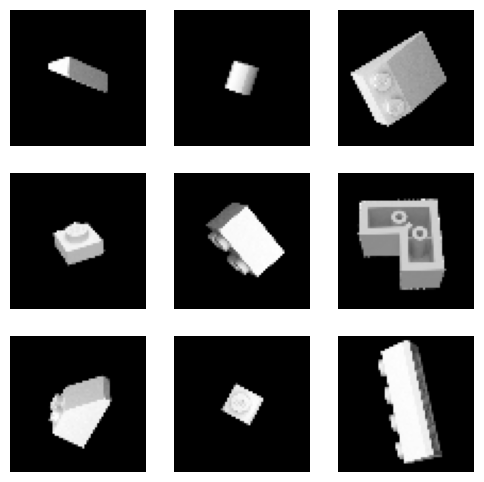

In [6]:
train = train_data.map(lambda x: (x / 127.5) - 1.0)

for batch in train_data.take(1):
    images = batch[:9]
    plt.figure(figsize=(6,6))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.axis("off")
    plt.show()

# WGAN

In [ ]:

# =========================
# CRITIC 
# =========================
def build_critic():
    input_img = layers.Input(shape=(64, 64, 1))
    x = layers.Conv2D(64, 4, 2, "same", use_bias=False)(input_img)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(128, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(256, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(512, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(1, 4, 1, "valid", use_bias=False)(x)       
    output = layers.Flatten()(x)
    return models.Model(input_img, output, name="Critic")


# =========================
# GENERATOR 
# =========================
def build_generator(latent_dim=100):
    input_z = layers.Input(shape=(latent_dim,))
    x = layers.Reshape((1, 1, latent_dim))(input_z)
    x = layers.Conv2DTranspose(512, 4, 1, "valid", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    x = layers.Conv2DTranspose(256, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    x = layers.Conv2DTranspose(128, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    x = layers.Conv2DTranspose(64, 4, 2, "same", use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.LeakyReLU(0.2)(x)
    
    output = layers.Conv2DTranspose(1, 4, 2, "same", use_bias=False, activation="tanh")(x)
    return models.Model(input_z, output, name="Generator")


# =========================
# WGAN avec weight clipping
# =========================
class WGAN(models.Model):
    def __init__(self, critic, generator, latent_dim=100, clip_value=0.01, n_critic=5):
        super(WGAN, self).__init__()
        self.critic = critic
        self.generator = generator
        self.latent_dim = latent_dim
        self.clip_value = clip_value
        self.n_critic = n_critic

    def compile(self, c_optimizer, g_optimizer):
        super(WGAN, self).compile()
        self.c_optimizer = c_optimizer
        self.g_optimizer = g_optimizer
        self.c_loss_metric = metrics.Mean(name="c_loss")
        self.g_loss_metric = metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.c_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        z = tf.random.normal((batch_size, self.latent_dim))

        for _ in range(self.n_critic):
            with tf.GradientTape() as tape:
                fake_images = self.generator(z, training=True)
                real_scores = self.critic(real_images, training=True)
                fake_scores = self.critic(fake_images, training=True)
                
                c_loss = -tf.reduce_mean(real_scores) + tf.reduce_mean(fake_scores)

            grads = tape.gradient(c_loss, self.critic.trainable_variables)
            self.c_optimizer.apply_gradients(zip(grads, self.critic.trainable_variables))

            # weight clipping 
            for var in self.critic.trainable_variables:
                var.assign(tf.clip_by_value(var, -self.clip_value, self.clip_value))

        # === gen ===
        with tf.GradientTape() as tape:
            fake_images = self.generator(z, training=True)
            fake_scores = self.critic(fake_images, training=True)
            g_loss = -tf.reduce_mean(fake_scores)

        grads_g = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(grads_g, self.generator.trainable_variables))

        self.c_loss_metric.update_state(c_loss)
        self.g_loss_metric.update_state(g_loss)

        return {"c_loss": self.c_loss_metric.result(), "g_loss": self.g_loss_metric.result()}


# =========================
# =========================
class GANMonitor(tf.keras.callbacks.Callback):
    def __init__(self, num_images=9, latent_dim=100):
        self.num_images = num_images
        self.latent_dim = latent_dim
        self.seed = tf.random.normal((num_images, latent_dim))

    def on_epoch_end(self, epoch, logs=None):
        generated = self.model.generator(self.seed, training=False)
        generated = (generated + 1.) / 2.   # [-1,1]  [0,1]
        plt.figure(figsize=(6,6))
        for i in range(self.num_images):
            plt.subplot(3, 3, i+1)
            plt.imshow(generated[i,:,:,0], cmap='gray')
            plt.axis('off')
        plt.suptitle(f"Epoch {epoch+1}")
        plt.show()


# =========================
# =========================
latent_dim = 100
critic = build_critic()
generator = build_generator(latent_dim)

wgan = WGAN(critic, generator, latent_dim=latent_dim, clip_value=0.01, n_critic=5)

wgan.compile(
    c_optimizer = optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    g_optimizer = optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
)


Epoch 1/10


I0000 00:00:1772125310.028799     139 service.cc:152] XLA service 0x7bb778031750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772125310.028846     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772125310.028851     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772125313.164483     139 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772125350.432812     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - c_loss: -9.1265e-06 - g_loss: -0.0020

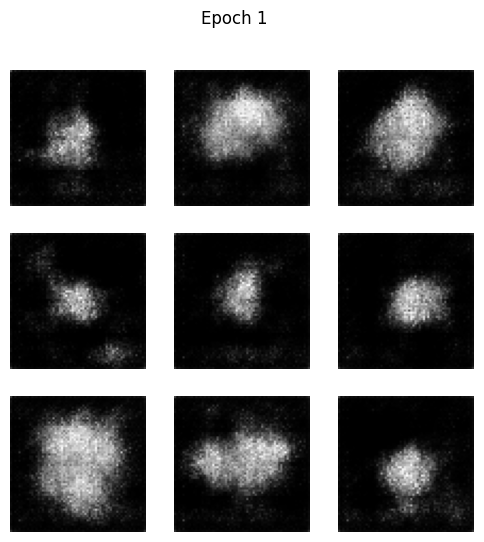

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 259s 140ms/step - c_loss: -9.1210e-06 - g_loss: -0.0020
Epoch 2/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - c_loss: -0.0439 - g_loss: 0.0232

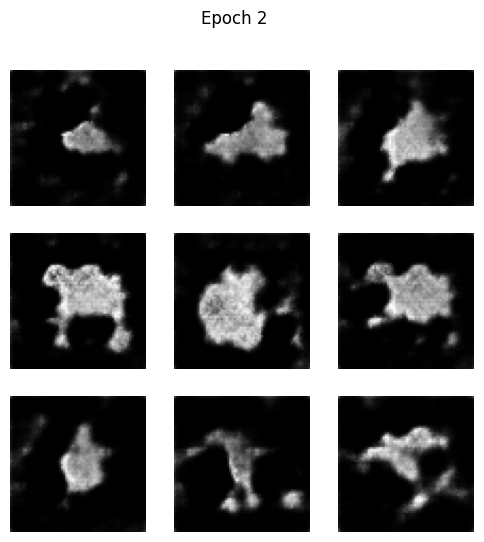

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 163s 112ms/step - c_loss: -0.0439 - g_loss: 0.0232
Epoch 3/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - c_loss: -0.1010 - g_loss: 0.0843

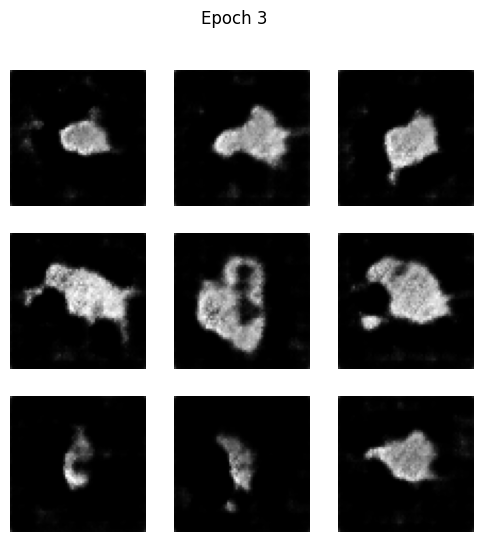

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 161s 111ms/step - c_loss: -0.1010 - g_loss: 0.0843
Epoch 4/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - c_loss: -0.0573 - g_loss: 0.0564

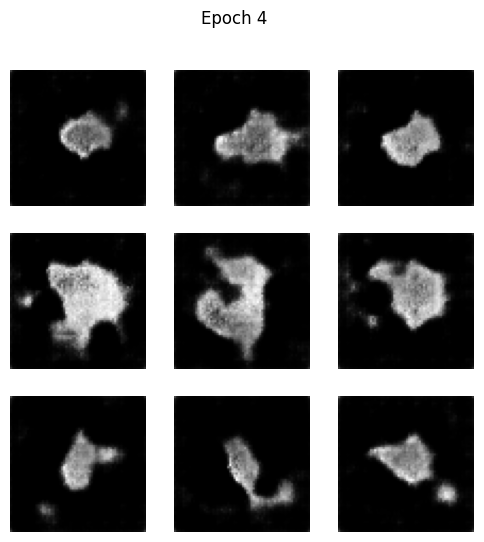

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 162s 112ms/step - c_loss: -0.0573 - g_loss: 0.0564
Epoch 5/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - c_loss: -0.0121 - g_loss: -0.0125

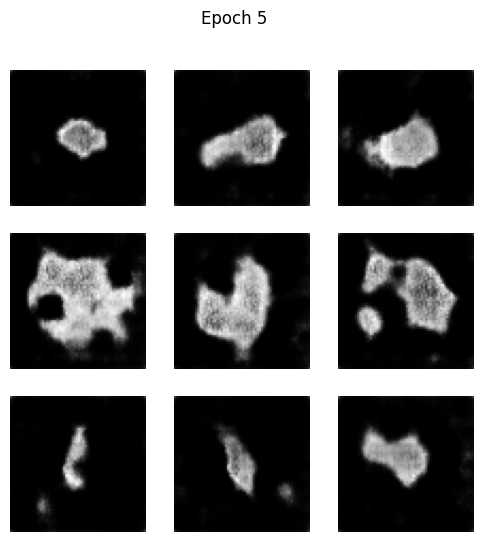

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 162s 112ms/step - c_loss: -0.0121 - g_loss: -0.0124
Epoch 6/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - c_loss: -0.0505 - g_loss: 0.0420

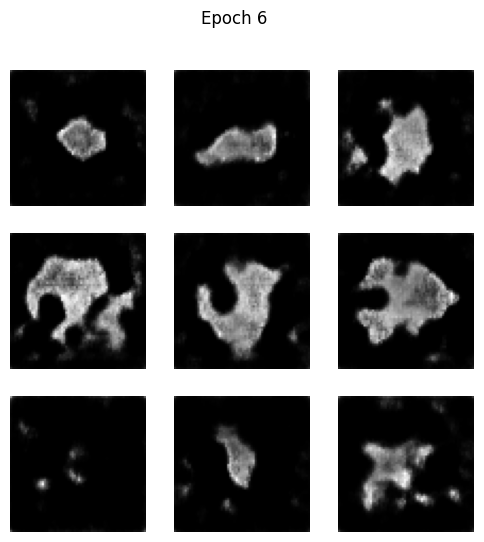

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 162s 112ms/step - c_loss: -0.0505 - g_loss: 0.0420
Epoch 7/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - c_loss: -0.0355 - g_loss: 0.0418

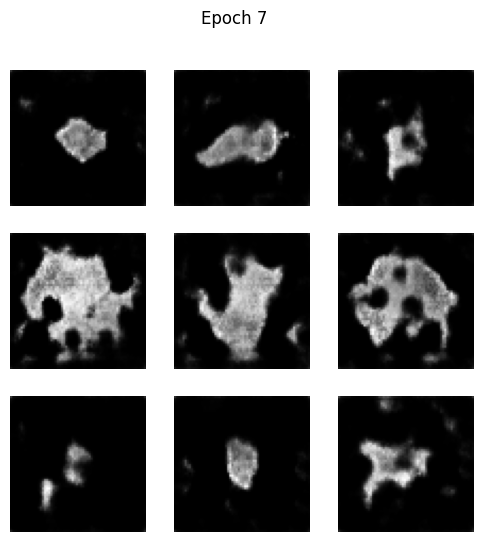

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 162s 112ms/step - c_loss: -0.0355 - g_loss: 0.0417
Epoch 8/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - c_loss: -0.0172 - g_loss: 0.0123

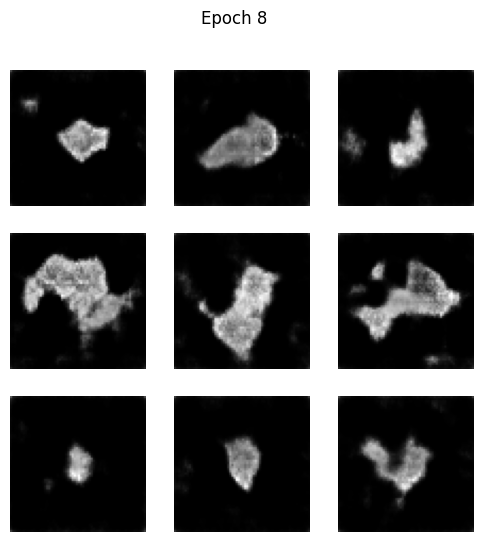

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 163s 112ms/step - c_loss: -0.0172 - g_loss: 0.0123
Epoch 9/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - c_loss: -0.0131 - g_loss: 0.0139

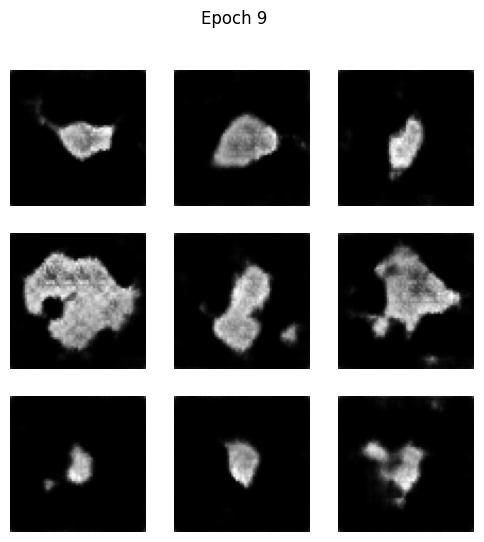

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 162s 112ms/step - c_loss: -0.0131 - g_loss: 0.0139
Epoch 10/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - c_loss: -0.0090 - g_loss: 0.0035

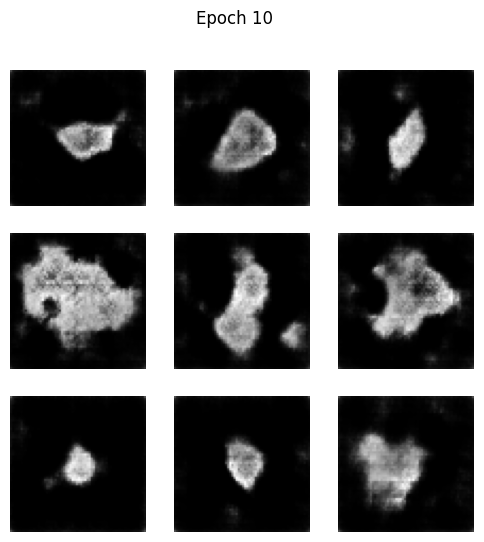

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 162s 112ms/step - c_loss: -0.0089 - g_loss: 0.0035


In [ ]:

wgan.fit(train, epochs=10, callbacks=[GANMonitor()])

_____

au lieu d'utiliser binary cross-entropy qui entraîne des problèmes de gradients qui disparaissent quand le discriminateur devient trop fort et d'instabilité extrême, le WGAN reformule le jeu adversaire en minimisant une approximation de la distance de Wasserstein-1 (Earth Mover's Distance),  
- le discriminateur est renommé critic, il ne classe plus en 0/1 mais produit un score réel, sa sortie est linéaire (pas de sigmoïde)
- entraîne le critic plusieurs fois (souvent 5 à 10 itérations) par mise à jour du générateur ; 
- pour que la distance de Wasserstein soit bien définie, le critic doit être contraint à être 1-Lipschitz (sa variation est bornée), ==>  weight clipping (on clippe brutalement tous les poids du critic dans un intervalle [-c, +c], typiquement c=0.01)

# WGAN-GP

In [ ]:


class WGAN_GP(models.Model):
    def __init__(self, critic, generator, latent_dim=100, gp_weight=10.0, n_critic=5):
        super(WGAN_GP, self).__init__()
        self.critic = critic
        self.generator = generator
        self.latent_dim = latent_dim
        self.gp_weight = gp_weight
        self.n_critic = n_critic

    def compile(self, c_optimizer, g_optimizer):
        super(WGAN_GP, self).compile()
        self.c_optimizer = c_optimizer
        self.g_optimizer = g_optimizer
        self.c_loss_metric = metrics.Mean(name="c_loss")
        self.g_loss_metric = metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.c_loss_metric, self.g_loss_metric]

    def gradient_penalty(self, real_images, fake_images):
        batch_size = tf.shape(real_images)[0]
        alpha = tf.random.uniform([batch_size, 1, 1, 1], 0., 1.)
        interpolates = alpha * real_images + (1 - alpha) * fake_images

        with tf.GradientTape() as tape:
            tape.watch(interpolates)
            pred = self.critic(interpolates, training=True)

        grads = tape.gradient(pred, [interpolates])[0]
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1,2,3]) + 1e-10)
        gp = tf.reduce_mean((norm - 1.) ** 2)
        return gp

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]
        z = tf.random.normal((batch_size, self.latent_dim))

        # === Critic ===
        for _ in range(self.n_critic):
            with tf.GradientTape() as tape:
                fake_images = self.generator(z, training=True)
                real_scores = self.critic(real_images, training=True)
                fake_scores = self.critic(fake_images, training=True)
                gp = self.gradient_penalty(real_images, fake_images)

                c_loss = -tf.reduce_mean(real_scores) + tf.reduce_mean(fake_scores)
                c_loss += self.gp_weight * gp

            grads = tape.gradient(c_loss, self.critic.trainable_variables)
            self.c_optimizer.apply_gradients(zip(grads, self.critic.trainable_variables))

        # === Generator ===
        with tf.GradientTape() as tape:
            fake_images = self.generator(z, training=True)
            fake_scores = self.critic(fake_images, training=True)
            g_loss = -tf.reduce_mean(fake_scores)

        grads_g = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(grads_g, self.generator.trainable_variables))

        self.c_loss_metric.update_state(c_loss)
        self.g_loss_metric.update_state(g_loss)

        return {"c_loss": self.c_loss_metric.result(), "g_loss": self.g_loss_metric.result()}



latent_dim = 100
critic = build_critic()
generator = build_generator(latent_dim)

wgan_gp = WGAN_GP(critic, generator, latent_dim=latent_dim, gp_weight=10.0, n_critic=5)

wgan_gp.compile(
    c_optimizer = optimizers.Adam(learning_rate=0.0001, beta_1=0.5, beta_2=0.9),
    g_optimizer = optimizers.Adam(learning_rate=0.0001, beta_1=0.5, beta_2=0.9)
)

# wgan_gp.fit(train_dataset, epochs=50, callbacks=[GANMonitor()])

Epoch 1/10


I0000 00:00:1772134259.449448     135 service.cc:152] XLA service 0x7a37e00028d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772134259.449498     135 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772134259.449504     135 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772134264.071516     135 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772134324.645982     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - c_loss: -123.6083 - g_loss: 75.6611

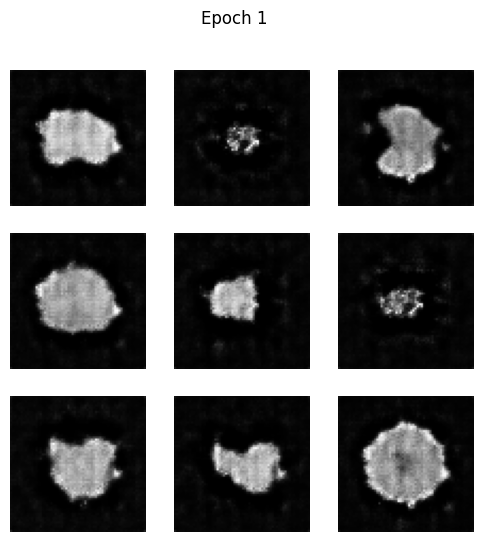

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 432s 236ms/step - c_loss: -123.5753 - g_loss: 75.6479
Epoch 2/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - c_loss: -43.7883 - g_loss: 6.7137

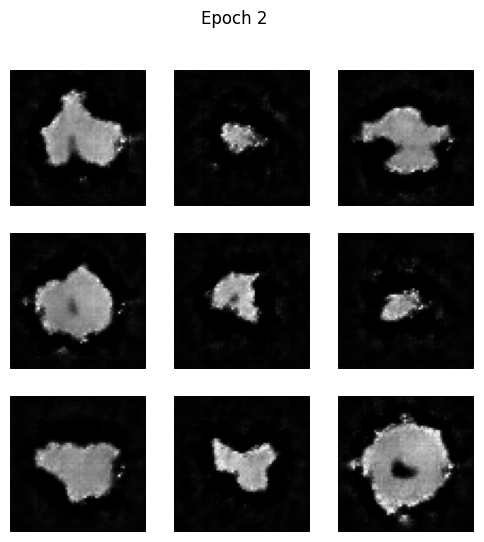

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 283s 195ms/step - c_loss: -43.7931 - g_loss: 6.7211
Epoch 3/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - c_loss: -44.7244 - g_loss: -4.1328

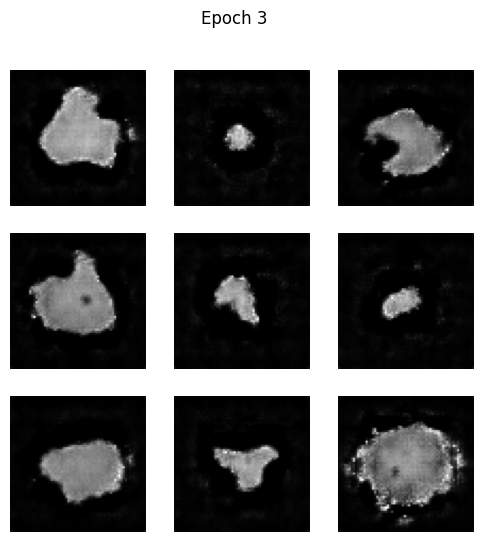

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 283s 195ms/step - c_loss: -44.7279 - g_loss: -4.1380
Epoch 4/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - c_loss: -68.0024 - g_loss: -17.9730

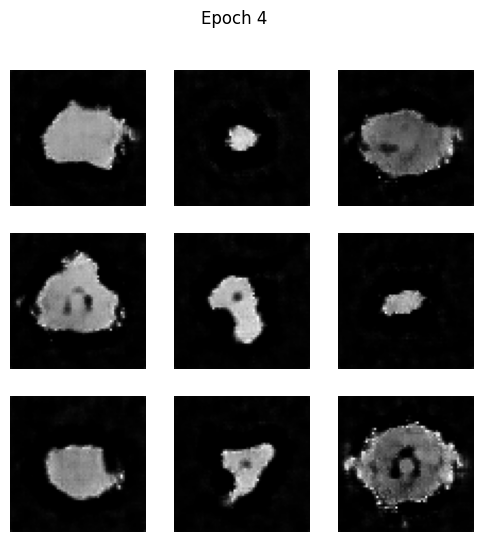

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 283s 195ms/step - c_loss: -68.0120 - g_loss: -17.9747
Epoch 5/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - c_loss: -79.6466 - g_loss: -9.1351

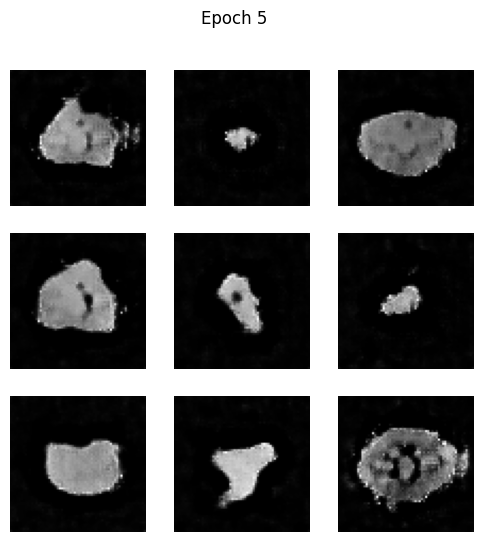

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 283s 195ms/step - c_loss: -79.6717 - g_loss: -9.1316
Epoch 6/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - c_loss: -203.5867 - g_loss: 13.5673

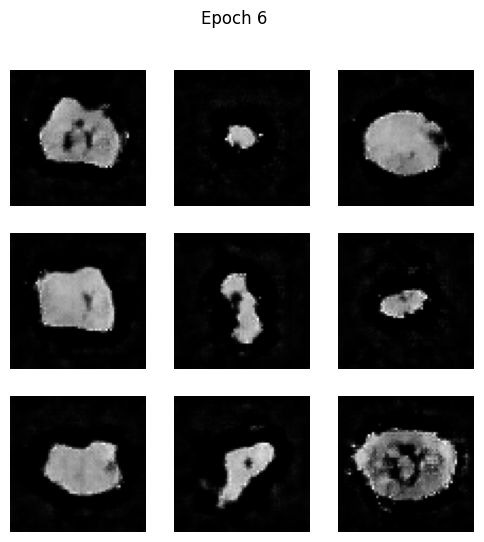

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 283s 195ms/step - c_loss: -203.5904 - g_loss: 13.5730
Epoch 7/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - c_loss: -237.8317 - g_loss: 41.0228

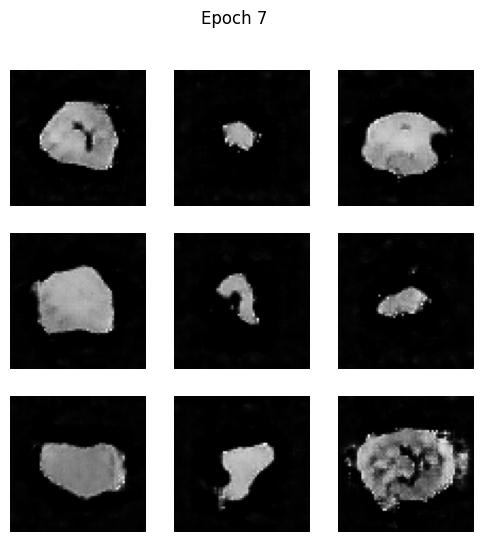

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 283s 195ms/step - c_loss: -237.8421 - g_loss: 41.0283
Epoch 8/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - c_loss: -339.6002 - g_loss: 104.4571

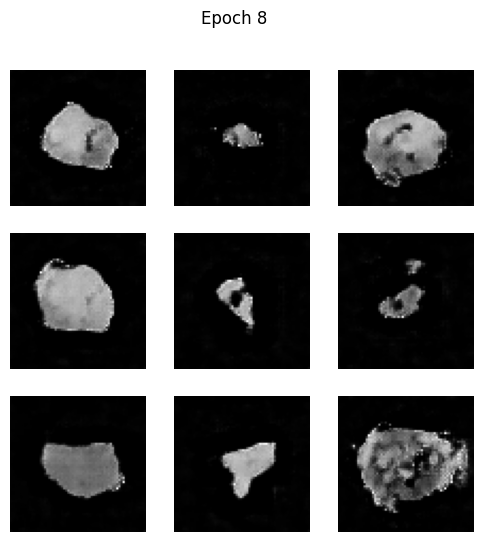

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 283s 195ms/step - c_loss: -339.5941 - g_loss: 104.4693
Epoch 9/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - c_loss: -379.1086 - g_loss: 146.5876

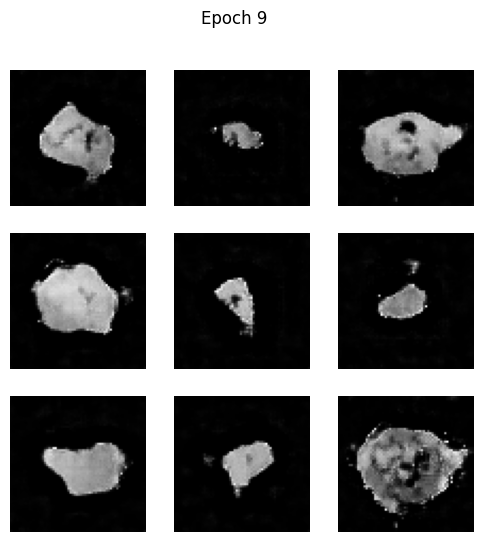

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 283s 195ms/step - c_loss: -379.1026 - g_loss: 146.6009
Epoch 10/10
1450/1450 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - c_loss: -254.5146 - g_loss: 220.7960

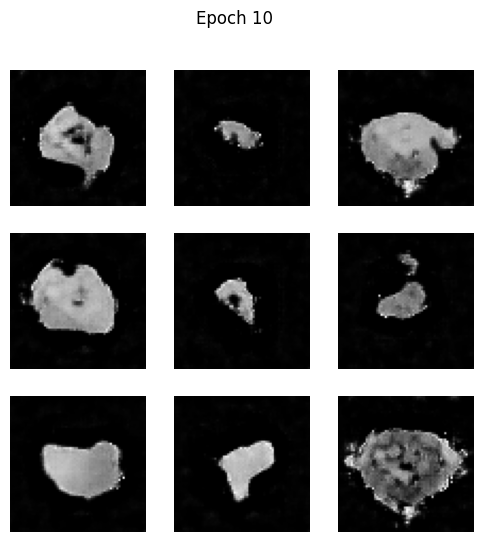

1450/1450 ━━━━━━━━━━━━━━━━━━━━ 283s 195ms/step - c_loss: -254.2637 - g_loss: 220.8047


In [10]:
wgan_gp.fit(train, epochs=10, callbacks=[GANMonitor()])